<a href="https://colab.research.google.com/github/DulaniDeSilva/Natural-Language-Processing-NLP-/blob/main/NLTK_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Introduction to Text preprocessing and NLTK

To build applications powered by Large Language Models (LLMs), we first need to understand how computers read and process text. This notebook covers the basics of that process using NLTK a popular Python library for working with text data.


# **What is NLTK?**

NLTK (Natural Language Toolkit) is a leading, free open source Python library used for Natural Language Processing (NLP) and text analysis.  It provides easy to use tools for tasks like tokenization, stemming, part-of-speach tagging and parsing.

**Installation**

In [ ]:
! pip install nltk

This will install the core NLTK library, which contain the main modules needed for text processing tasks.

**Download NLTK Resources**

After installation, download NLTK's pre packaged datasets and tools.

In [ ]:
import nltk

nltk.download('punkt')  #Tokenizers for sentence and word tokenization
nltk.download('stopwords')  #List of common stop words
nltk.download('wordnet')  #WordNet lexical database for Lemmatization
nltk.download('averaged_perceptron_tagger_eng') #Part of speech tagger
nltk.download('maxent_ne_chunker_tab') #Named Entity Recognition model
nltk.download('words') #Word corpus for NER
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker_tab.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

Instead of downlaoding one by one you can download all available NTLK datasets, models and corpora at once using the following code snippet. But usually it is not recommended because it downloads a very large amount of data, takes more time and space.

In [ ]:
# import nltk
# nltk.download('all')

##**Regular Expressions**

What are Regualr Expressions?

Regular expression is used to effectively match patterns on strings. Simply it is a instruction given to a function on what and how to match or replace a set of strings. We can use pattern extrication to get meaningful information from large amounts of messy text data. The following are some regular expression that we need.



*   (a period): This expression matches any single character except newline \n.
*   \w: This exression will match a character or digital equivalent to [a-z A-Z 0-9]

*   \W: (uppercase W) matches any non word character
*   \s: Matches a single whitespace character - space, newline, return, tab, form [\n\r\t\f]
* \S: This matches any non whitespace character
* \t: This preforms tab operation
* \n: This is used for newline character
* \r: This is used for return character
* \d: Decimal digit [0-9]
* ^: This is used at the start of the string
* "$" : This is used at the end of the string.







If you need to nullify the specialness of the special character then you can use "\\". For example you want to match the $ symbol then add \ infront of it.

In Python, regular expressions are used with the "re" module.

In [ ]:
import re

Lets consider following example to see how different regular expressions work on the text.

In [ ]:
text = """
Large Language Models (LLMs) are AI systems used in NLP.
ChatGPT was released in 2022.
Researchers use Python, deep learning, and transformers for NLP tasks.

Email: llmresearch@gmail.com
Website: www.llm-ai.com
"""

In [ ]:
import re

# Find all words using \w
words = re.findall(r"\w+", text)   #\w+ finds words and numbers, + means one or more characters
print("Words are:", words)

# find numbers using \d
numbers = re.findall(r"\d+", text)
print("Numbers are:", numbers)

# find non word characters using \W
symbols = re.findall(r"\W", text)
print(symbols[:20])

# find email pattern
email = re.findall(r"\w+@\w+.\w+", text)
print("Email is:", email)



Words are: ['Large', 'Language', 'Models', 'LLMs', 'are', 'AI', 'systems', 'used', 'in', 'NLP', 'ChatGPT', 'was', 'released', 'in', '2022', 'Researchers', 'use', 'Python', 'deep', 'learning', 'and', 'transformers', 'for', 'NLP', 'tasks', 'Email', 'llmresearch', 'gmail', 'com', 'Website', 'www', 'llm', 'ai', 'com']
Numbers are: ['2022']
['\n', ' ', ' ', ' ', '(', ')', ' ', ' ', ' ', ' ', ' ', ' ', '.', '\n', ' ', ' ', ' ', ' ', '.', '\n']
Email is: ['llmresearch@gmail.com']


## **Text wrangling and cleaning (Text Preprocessing)**

Text data collected from real world sources are usually messy and unstructured.(For exmaple it could include symbols, missing values, extra spaces, punctuations, HTML tags, mixed formats etc) So before using text for any NLP task we need to clean and organize it. This process is called Text Wrangling and Cleansing. The process includes data munging, text cleansing, specific preprocessing, tokenization, stemming or lemmatization and stop word removal.

### Loading data

Before performing NLP taks such as tokenization, lemmatization, stop word removal first we need to load the text data. Normally these text data is stored in files such as CSV files, JSON files, TXT files, databases or web pages.

Models and NLP libraries cannot directly understand CSV structure, JSON structure or database tables. They only process text data after it is extracted and converted into strings.

For the demonstration first we will create a csv file.

In [ ]:
import csv

rows = [
    ["id", "text", "category"],
    [1, "Large Language Models like GPT-4 are transforming NLP.", "LLM"],
    [2, "BERT introduced bidirectional training for transformers.", "LLM"],
    [3, "ChatGPT was released by OpenAI in November 2022.", "LLM"],
    [4, "Tokenization splits text into smaller units called tokens.", "NLP"],
    [5, "Fine-tuning adapts a pre-trained LLM to a specific task.", "LLM"],
]

with open('example.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerows(rows)

print("CSV file created successfully.")

CSV file created successfully.


Once created we can load and visualize it using pandas.

In [ ]:
import pandas as pd
df = pd.read_csv('example.csv')
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")
display(df)

Shape: 5 rows × 3 columns



,id,text,category
0,1,Large Language Models like GPT-4 are transform...,LLM
1,2,BERT introduced bidirectional training for tra...,LLM
2,3,ChatGPT was released by OpenAI in November 2022.,LLM
3,4,Tokenization splits text into smaller units ca...,NLP
4,5,Fine-tuning adapts a pre-trained LLM to a spec...,LLM


Extracting the text columns

In [ ]:
texts = df['text'].tolist()

# Show extracted texts
for i, t in enumerate(texts):
    print(f"[{i+1}] {t}")

[1] Large Language Models like GPT-4 are transforming NLP.
[2] BERT introduced bidirectional training for transformers.
[3] ChatGPT was released by OpenAI in November 2022.
[4] Tokenization splits text into smaller units called tokens.
[5] Fine-tuning adapts a pre-trained LLM to a specific task.


If we have json type file the following code snippets demonstrates how to load the data.

In [ ]:
import json

#Creating a sample JSON file (If you already have a json file you can directly load it here.)
data_to_write = [
    {"id": 1, "text": "Large Language Models are revolutionizing AI.", "year": 2023},
    {"id": 2, "text": "GPT-4 can reason across text, images, and code.", "year": 2023},
    {"id": 3, "text": "Prompt engineering is key to working with LLMs.", "year": 2024},
]

with open('example.json', 'w') as f:
    json.dump(data_to_write, f, indent=2)

#Load
with open('example.json', 'r') as f:
    data = json.load(f)

# Display as DataFrame
df_json = pd.DataFrame(data)
display(df_json)

#Extract texts
json_texts = [item['text'] for item in data]
for i, t in enumerate(json_texts):
    print(f"[{i+1}] {t}")

,id,text,year
0,1,Large Language Models are revolutionizing AI.,2023
1,2,"GPT-4 can reason across text, images, and code.",2023
2,3,Prompt engineering is key to working with LLMs.,2024


[1] Large Language Models are revolutionizing AI.
[2] GPT-4 can reason across text, images, and code.
[3] Prompt engineering is key to working with LLMs.


## Text Cleansing

Once we have parsed the text from variety of data sources, next we have to preprocess our data. By performing text preprocessing it improves model accuracy, reduce noise in data, reduce unneccessary information and improve tokenization and feature extraction.

We will use the following sentence for all preprocessing examples.

In [ ]:
text = """
OMG!!! Large Language Models (LLMs) are AMAZING 😃.
ChatGPT was released in 2022!!! It's trained on 570GB of data.
I can't believe how fast NLP is growing...
Won't these models replace human translators??
Visit: www.ai-example.com for more info!!!
"""

1. **Lowercasing**:
Computers can treat NLP, nlp, Nlp as differnt words. Lowercasing makes all words consistent.

In [ ]:
lower_text = text.lower()
print(lower_text)


omg!!! large language models (llms) are amazing 😃.
chatgpt was released in 2022!!! it's trained on 570gb of data.
i can't believe how fast nlp is growing...    
won't these models replace human translators??
visit: www.ai-example.com for more info!!!



2. **Removing punctuations**: Punctuations usually does not add meaning in many NLP tasks.

In [ ]:
import re

no_punctuation = re.sub(r"[^\w\s]", "", text)

print(no_punctuation)


OMG Large Language Models LLMs are AMAZING 
ChatGPT was released in 2022 Its trained on 570GB of data
I cant believe how fast NLP is growing    
Wont these models replace human translators
Visit wwwaiexamplecom for more info



3. **Removing Numbers**: Numbers may not always be useful.

In [ ]:
remove_numbers = re.sub(r"\d+", "", text)

print(remove_numbers)


OMG!!! Large Language Models (LLMs) are AMAZING 😃.
ChatGPT was released in !!! It's trained on GB of data.
I can't believe how fast NLP is growing...    
Won't these models replace human translators??
Visit: www.ai-example.com for more info!!!



4. **Removing extra whitespaces**: Text may contain extra spaces, tabs, new lines. These create inconsistent formatting.

In [ ]:
clean_spaces = " ".join(text.split())

print(clean_spaces)

OMG!!! Large Language Models (LLMs) are AMAZING 😃. ChatGPT was released in 2022!!! It's trained on 570GB of data. I can't believe how fast NLP is growing... Won't these models replace human translators?? Visit: www.ai-example.com for more info!!!


5. **Removing special symbols**: Special symbols and emojis may introduce noise depending on the NLP task. But sometimes they can be useful, sometimes not.

In [ ]:
clean_symbols = re.sub(r"[^a-zA-Z0-9\s]", "", text)

print(clean_symbols)


OMG Large Language Models LLMs are AMAZING 
ChatGPT was released in 2022 Its trained on 570GB of data
I cant believe how fast NLP is growing    
Wont these models replace human translators
Visit wwwaiexamplecom for more info



6. **Expanding contractions**: Constractions create inconsistencies. For example
* can't -> cannot
* won't -> will not
* I'm -> I am
Expanding contractions imporves text understanding and token consistency.

In [ ]:
contractions = {
    "can't": "cannot",
    "won't": "will not",
    "i'm": "i am",
    "it's": "it is",
    "don't": "do not",
    "isn't": "is not",
}

text_lower = text.lower()

for word, expansion in contractions.items():
    text_lower = text_lower.replace(word, expansion)

print(text_lower)


omg!!! large language models (llms) are amazing 😃.
chatgpt was released in 2022!!! it is trained on 570gb of data.
i cannot believe how fast nlp is growing...    
will not these models replace human translators??
visit: www.ai-example.com for more info!!!



***NOTE*** : Not all preprocessing techniques should always be applied.

For example
* emojis may be useful in sentiment analysis
* numbers may be important in financial data
* punctuations may matter in grammer analysis

So the preprocesing pipeline depends on the NLP taks, the dataset and application requirments.  

After performing text preprocessing we can apply NLP tasks such as sentence splitting, tokenization, stop word removal, stemming, lemmatization, rare word removal, spell correction, POS tagging. These can be done using the Natural Language Toolkit (NLTK).

In [ ]:
#For clear demonstration we will use the following single paragraph across all the demonstrations below.

nlp_text = """
Large Language Models, or LLMs, are advanced neural network systems developed
by organizations like OpenAI, Google, and Anthropic. OpenAI released ChatGPT
in November 2022, and it quickly became one of the most widely used AI tools
globally. Google introduced Gemini in 2023, while Meta released the open-source
LLaMA models for researchers and developers. These models are built on transformer
architectures, which use attention mechanisms to process and generate text
efficiently. Researchers at Stanford University, MIT, and DeepMind are studying
how LLMs can be fine-tuned for tasks like summarization, translation, and
question answering. However, LLMs can sometimes hallucinate facts or produce
biased outputs, which raises ethical concerns in the AI community. Despite these
challenges, companies like Microsoft, Amazon, and Anthropic continue investing
heavily in LLM research. The rapid growth of NLP has created exciting
opportunities for developers and researchers worldwide.
"""

***Sentence Splitter***

Some of the NLP applications require splitting a large raw text into sentences to get more meaningful information out.

In [ ]:
from nltk.tokenize import sent_tokenize

sentences = sent_tokenize(nlp_text)

print(f"Total sentences found: {len(sentences)}\n")
for i, sentence in enumerate(sentences, 1):
    print(f"Sentence {i}: {sentence}")

Total sentences found: 8

Sentence 1: 
Large Language Models, or LLMs, are advanced neural network systems developed 
by organizations like OpenAI, Google, and Anthropic.
Sentence 2: OpenAI released ChatGPT 
in November 2022, and it quickly became one of the most widely used AI tools 
globally.
Sentence 3: Google introduced Gemini in 2023, while Meta released the open-source 
LLaMA models for researchers and developers.
Sentence 4: These models are built on transformer 
architectures, which use attention mechanisms to process and generate text 
efficiently.
Sentence 5: Researchers at Stanford University, MIT, and DeepMind are studying 
how LLMs can be fine-tuned for tasks like summarization, translation, and 
question answering.
Sentence 6: However, LLMs can sometimes hallucinate facts or produce 
biased outputs, which raises ethical concerns in the AI community.
Sentence 7: Despite these 
challenges, companies like Microsoft, Amazon, and Anthropic continue investing 
heavily in LLM re

sent_tokenize uses a general purpose instance already trained on many european languages, making boundaries based on standard letters and punctuations. But if we want custom training "PunktSentenceTokenizer" can be used. It provides ability to train a custom tokenizer on raw text. This is useful for text with non standard punctuation or unique formattng.

In [ ]:
import nltk.tokenize.punkt as punkt

custom_sent_tokenizer = punkt.PunktSentenceTokenizer()
custom_sent_tokenizer.train(nlp_text)

custom_sentences = custom_sent_tokenizer.tokenize(nlp_text)

print(f"Default sent_tokenize → {len(sentences)} sentences")
print(f"Custom tokenizer      → {len(custom_sentences)} sentences\n")

for i, s in enumerate(custom_sentences, 1):
    print(f"[{i}] {s}")

Default sent_tokenize → 8 sentences
Custom tokenizer      → 8 sentences

[1] 
Large Language Models, or LLMs, are advanced neural network systems developed 
by organizations like OpenAI, Google, and Anthropic.
[2] OpenAI released ChatGPT 
in November 2022, and it quickly became one of the most widely used AI tools 
globally.
[3] Google introduced Gemini in 2023, while Meta released the open-source 
LLaMA models for researchers and developers.
[4] These models are built on transformer 
architectures, which use attention mechanisms to process and generate text 
efficiently.
[5] Researchers at Stanford University, MIT, and DeepMind are studying 
how LLMs can be fine-tuned for tasks like summarization, translation, and 
question answering.
[6] However, LLMs can sometimes hallucinate facts or produce 
biased outputs, which raises ethical concerns in the AI community.
[7] Despite these 
challenges, companies like Microsoft, Amazon, and Anthropic continue investing 
heavily in LLM research.
[

***Tokenization***

A word/ token is the minimal unit that a machine can understand and process. So any text string cannot be further processed without going through tokenization. Tokenization is the process of splitting the raw string into meaningful tokens. The complexity of tokenization varies according to the need of the NLP application,and the complexity of the langugae itself.

Sentence tokenization - splits the text into sentences.

Word tokenization - splits the text into words and punctuation marks.

Word Tokenization

In [ ]:
from nltk.tokenize import word_tokenize

word_tokens = word_tokenize(nlp_text)

print(f"Total tokens: {len(word_tokens)}\n")
print("First 30 tokens:")
print(word_tokens[:30])

Total tokens: 163

First 30 tokens:
['Large', 'Language', 'Models', ',', 'or', 'LLMs', ',', 'are', 'advanced', 'neural', 'network', 'systems', 'developed', 'by', 'organizations', 'like', 'OpenAI', ',', 'Google', ',', 'and', 'Anthropic', '.', 'OpenAI', 'released', 'ChatGPT', 'in', 'November', '2022', ',']


Sentence Tokenization

In [ ]:
sent_tokens = sent_tokenize(nlp_text)

print(f"Number of sentences: {len(sent_tokens)}\n")
for i, sent in enumerate(sent_tokens, 1):
    words_in_sent = word_tokenize(sent)
    print(f"Sentence {i} ({len(words_in_sent)} tokens): {sent}")

Number of sentences: 8

Sentence 1 (23 tokens): 
Large Language Models, or LLMs, are advanced neural network systems developed 
by organizations like OpenAI, Google, and Anthropic.
Sentence 2 (21 tokens): OpenAI released ChatGPT 
in November 2022, and it quickly became one of the most widely used AI tools 
globally.
Sentence 3 (18 tokens): Google introduced Gemini in 2023, while Meta released the open-source 
LLaMA models for researchers and developers.
Sentence 4 (19 tokens): These models are built on transformer 
architectures, which use attention mechanisms to process and generate text 
efficiently.
Sentence 5 (27 tokens): Researchers at Stanford University, MIT, and DeepMind are studying 
how LLMs can be fine-tuned for tasks like summarization, translation, and 
question answering.
Sentence 6 (21 tokens): However, LLMs can sometimes hallucinate facts or produce 
biased outputs, which raises ethical concerns in the AI community.
Sentence 7 (19 tokens): Despite these 
challenges, com

Custom tokenization

There are two most commonly used tokenizers. The first is word_tokenize which is the default one and will work in most cases. The other one is regex_tokenize, which is more of a customized tokenizer for the specific needs of the user.

In [ ]:
from nltk.tokenize import regexp_tokenize, wordpunct_tokenize

# Pattern 1: Only alphabetic words (no numbers, no punctuation)
alpha_only = regexp_tokenize(nlp_text, pattern=r'[a-zA-Z]+')
print("Alpha-only tokens (first 20):", alpha_only[:20])

# Pattern 2: Words including hyphens and apostrophes (e.g. "fine-tuned", "LLMs")
word_with_hyph = regexp_tokenize(nlp_text, pattern=r"[a-zA-Z]+(?:[-'][a-zA-Z]+)*")
print("\nTokens including hyphens/apostrophes (first 20):", word_with_hyph[:20])

# Pattern 3: Uppercase acronyms only (e.g. LLMs, NLP, MIT, AI)
acronyms = regexp_tokenize(nlp_text, pattern=r'\b[A-Z]{2,}\b')
print("\nAcronyms found:", acronyms)

# wordpunct splits on whitespace AND separates punctuation as tokens
wordpunct_tokens = wordpunct_tokenize(nlp_text)
print("\nwordpunct tokens (first 20):", wordpunct_tokens[:20])

Alpha-only tokens (first 20): ['Large', 'Language', 'Models', 'or', 'LLMs', 'are', 'advanced', 'neural', 'network', 'systems', 'developed', 'by', 'organizations', 'like', 'OpenAI', 'Google', 'and', 'Anthropic', 'OpenAI', 'released']

Tokens including hyphens/apostrophes (first 20): ['Large', 'Language', 'Models', 'or', 'LLMs', 'are', 'advanced', 'neural', 'network', 'systems', 'developed', 'by', 'organizations', 'like', 'OpenAI', 'Google', 'and', 'Anthropic', 'OpenAI', 'released']

Acronyms found: ['AI', 'MIT', 'AI', 'LLM', 'NLP']

wordpunct tokens (first 20): ['Large', 'Language', 'Models', ',', 'or', 'LLMs', ',', 'are', 'advanced', 'neural', 'network', 'systems', 'developed', 'by', 'organizations', 'like', 'OpenAI', ',', 'Google', ',']


***Stop Word Removal***

Stopwords are common words such as "the", "and", or "is" that occur frequently but carry little meaning in most analysis. Removing these words helps focus on the more meaningful words in the text.

In [ ]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

# Filter: keep only alphabetic words that are NOT stop words
filtered_words = [
    word for word in word_tokens
    if word.isalpha() and word.lower() not in stop_words
]

print(f"Original token count : {len(word_tokens)}")
print(f"After stop word removal: {len(filtered_words)}")
print(f"\nRemoved words (sample stop words found): "
      f"{[w for w in word_tokens if w.lower() in stop_words][:15]}")
print(f"\nFiltered words (first 30): {filtered_words[:30]}")

Original token count : 163
After stop word removal: 93

Removed words (sample stop words found): ['or', 'are', 'by', 'and', 'in', 'and', 'it', 'of', 'the', 'most', 'in', 'while', 'the', 'for', 'and']

Filtered words (first 30): ['Large', 'Language', 'Models', 'LLMs', 'advanced', 'neural', 'network', 'systems', 'developed', 'organizations', 'like', 'OpenAI', 'Google', 'Anthropic', 'OpenAI', 'released', 'ChatGPT', 'November', 'quickly', 'became', 'one', 'widely', 'used', 'AI', 'tools', 'globally', 'Google', 'introduced', 'Gemini', 'Meta']


***Stemming***

Stemming is the process of reducing words to their root form by removing affixes like suffizes and prefixes. The root form may not always be a valid word in the dictionary, but it helps in standardizing variations of the same word. (eg: studying -> studi)

Porter Stemmer is a common stemming algorithm that works by removing suffixes.

In [ ]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

stemmed_words = [stemmer.stem(word) for word in filtered_words]

print(f"{'Original':<20} {'Stemmed':<20}")
print("-" * 40)
for original, stemmed in zip(filtered_words[:20], stemmed_words[:20]):
    print(f"{original:<20} {stemmed:<20}")

Original             Stemmed             
----------------------------------------
Large                larg                
Language             languag             
Models               model               
LLMs                 llm                 
advanced             advanc              
neural               neural              
network              network             
systems              system              
developed            develop             
organizations        organ               
like                 like                
OpenAI               openai              
Google               googl               
Anthropic            anthrop             
OpenAI               openai              
released             releas              
ChatGPT              chatgpt             
November             novemb              
quickly              quickli             
became               becam               


***Lemmatization***

Lemmatization is similar to stemming in that it also reduces words to their base form. But unlike stemming, lemmatization returns valid dictionary words. For example the words "running" and "ran" would be reduced to "run".

Lemmatization generally produces more accurate results than stemming, as it keeps the word in a recognizable form. The tool for lemmatization in NLTK is WordNetLemmatizer, which uses WordNet lexical database.

In [ ]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

# Lemmatize as verbs (pos='v') to catch forms like "studying", "raised"
lemmatized_words = [lemmatizer.lemmatize(word, pos='v') for word in filtered_words]

print(f"{'Original':<20} {'Stemmed':<20} {'Lemmatized':<20}")
print("-" * 60)
for orig, stem, lemma in zip(filtered_words[:20], stemmed_words[:20], lemmatized_words[:20]):
    print(f"{orig:<20} {stem:<20} {lemma:<20}")

Original             Stemmed              Lemmatized          
------------------------------------------------------------
Large                larg                 Large               
Language             languag              Language            
Models               model                Models              
LLMs                 llm                  LLMs                
advanced             advanc               advance             
neural               neural               neural              
network              network              network             
systems              system               systems             
developed            develop              develop             
organizations        organ                organizations       
like                 like                 like                
OpenAI               openai               OpenAI              
Google               googl                Google              
Anthropic            anthrop              Anthropic      

Lemmatization is useful when we want to reduce words to their base form but still retain their meaning. It is a more accurate and context sensitive method compared to stemming.

***Rare word Removal***

Rare words (appearing only once or very few times) may be noise or typos.
Removing them can improve model performance on large corpora.

In [ ]:
from collections import Counter

# Use all alpha tokens (lowercased) from the full text for frequency counting
all_alpha_tokens = [w.lower() for w in word_tokens if w.isalpha()]

freq = Counter(all_alpha_tokens)

print("Word frequency distribution:")
print(f"  Total unique words : {len(freq)}")
print(f"  Words appearing once: {sum(1 for f in freq.values() if f == 1)}")

# Words that appear only once are "rare" in this text
rare_words = [word for word, count in freq.items() if count == 1]
common_words = [word for word, count in freq.items() if count > 1]

print(f"\nRare words (appear only once): {rare_words}")
print(f"\nNon-rare words (appear more than once): {common_words}")

# Filter the token list to remove rare words
tokens_no_rare = [w for w in all_alpha_tokens if w not in rare_words]
print(f"\nOriginal token count : {len(all_alpha_tokens)}")
print(f"After rare word removal: {len(tokens_no_rare)}")

Word frequency distribution:
  Total unique words : 99
  Words appearing once: 79

Rare words (appear only once): ['large', 'language', 'advanced', 'neural', 'network', 'systems', 'developed', 'by', 'organizations', 'chatgpt', 'november', 'it', 'quickly', 'became', 'one', 'most', 'widely', 'used', 'tools', 'globally', 'introduced', 'gemini', 'while', 'meta', 'llama', 'built', 'on', 'transformer', 'architectures', 'use', 'attention', 'mechanisms', 'to', 'process', 'generate', 'text', 'efficiently', 'at', 'stanford', 'university', 'mit', 'deepmind', 'studying', 'how', 'be', 'tasks', 'summarization', 'translation', 'question', 'answering', 'however', 'sometimes', 'hallucinate', 'facts', 'produce', 'biased', 'outputs', 'raises', 'ethical', 'concerns', 'community', 'despite', 'challenges', 'companies', 'microsoft', 'amazon', 'continue', 'investing', 'heavily', 'llm', 'research', 'rapid', 'growth', 'nlp', 'has', 'created', 'exciting', 'opportunities', 'worldwide']

Non-rare words (appear mor

***Spell Correction***

Real world text often contain typos/ errors.

In [ ]:
# Misspelled version of our topic text
misspelled_text = """
Larg Languge Modells, or LLMs, are advnced nural network sistems developed
by organizashuns like OpenAI, Gogle, and Anthropic. These modls are bilt on
transfomer architecturs and use attenshun mechanizms to procces text efficienly.
"""

print("Original (misspelled):")
print(misspelled_text)

# Dictionary-based correction (manual mapping — best for controlled demos)
corrections = {
    "larg": "large",
    "languge": "language",
    "modells": "models",
    "advnced": "advanced",
    "nural": "neural",
    "sistems": "systems",
    "organizashuns": "organizations",
    "gogle": "google",
    "modls": "models",
    "bilt": "built",
    "transfomer": "transformer",
    "architecturs": "architectures",
    "attenshun": "attention",
    "mechanizms": "mechanisms",
    "procces": "process",
    "efficienly": "efficiently",
}

corrected_text = misspelled_text.lower()
for wrong, right in corrections.items():
    corrected_text = corrected_text.replace(wrong, right)

print("\nAfter spell correction:")
print(corrected_text)

# ── Optional: using pyspellchecker library for automatic correction ────────────
# Uncomment to use automatic spell checker (install first)
# !pip install pyspellchecker -q
# from spellchecker import SpellChecker
# spell = SpellChecker()
# words_to_check = misspelled_text.lower().split()
# misspelled = spell.unknown(words_to_check)
# print("\nDetected misspellings:", misspelled)
# for word in misspelled:
#     print(f"  {word} → {spell.correction(word)}")

Original (misspelled):

Larg Languge Modells, or LLMs, are advnced nural network sistems developed 
by organizashuns like OpenAI, Gogle, and Anthropic. These modls are bilt on 
transfomer architecturs and use attenshun mechanizms to procces text efficienly.


After spell correction:

large language models, or llms, are advanced neural network systems developed 
by organizations like openai, google, and anthropic. these models are built on 
transformer architectures and use attention mechanisms to process text efficiently.



Part-of-Speech (POS) Tagging

Part-of-speech(POS) tagging involves identifying the grammatical category of each word in a sentence, such as nouns, verbs, adjectives, adverbs, and more. This helps in understanding the syntactic structure of a sentence, enabling better handling of tasks such as text parsing, information extraction and machine translation.

POS tagging assigns labels to words in a sentence. Tagging helps analyze the syntax of the sentence and understand word functions in context.

With NLTK, we can perform POS tagging using the pos_tag function, which tags each word in a list of tokens with its part of speech.

Common tags are:
* NN -> Noun
* VB -> verb
* JJ -> adjective
* RB -> adverb
* PRP -> pronoun
* DT -> determiner
* IN -> preposition

In [ ]:
from nltk import pos_tag

demo_text = "OpenAI released ChatGPT in November 2022, and it quickly became one of the most widely used AI tools globally."

demo_tokens = word_tokenize(demo_text)
tagged_words = pos_tag(demo_tokens)

print("POS-tagged tokens:\n")
print(f"{'Token':<20} {'POS Tag':<10} {'Meaning':<25}")
print("-" * 55)

tag_meanings = {
    'NNP': 'Proper Noun (singular)', 'NNPS': 'Proper Noun (plural)',
    'NN': 'Noun (singular)', 'NNS': 'Noun (plural)',
    'VBD': 'Verb (past tense)', 'VBZ': 'Verb (3rd person sg)',
    'VBN': 'Verb (past participle)', 'VB': 'Verb (base)',
    'JJ': 'Adjective', 'JJS': 'Adjective (superlative)',
    'RB': 'Adverb', 'IN': 'Preposition',
    'DT': 'Determiner', 'CC': 'Coordinating Conj.',
    'CD': 'Cardinal Number', 'PRP': 'Personal Pronoun',
    ',': 'Comma', '.': 'Period',
}

for token, tag in tagged_words:
    meaning = tag_meanings.get(tag, tag)
    print(f"{token:<20} {tag:<10} {meaning:<25}")

POS-tagged tokens:

Token                POS Tag    Meaning                  
-------------------------------------------------------
OpenAI               NNP        Proper Noun (singular)   
released             VBD        Verb (past tense)        
ChatGPT              NNP        Proper Noun (singular)   
in                   IN         Preposition              
November             NNP        Proper Noun (singular)   
2022                 CD         Cardinal Number          
,                    ,          Comma                    
and                  CC         Coordinating Conj.       
it                   PRP        Personal Pronoun         
quickly              RB         Adverb                   
became               VBD        Verb (past tense)        
one                  CD         Cardinal Number          
of                   IN         Preposition              
the                  DT         Determiner               
most                 RBS        RBS                   

Extract specific POS categories

In [ ]:
full_tokens = word_tokenize(nlp_text)
full_tagged = pos_tag(full_tokens)

# Extract by category
proper_nouns = [w for w, t in full_tagged if t == 'NNP']
common_nouns = [w for w, t in full_tagged if t in ('NN', 'NNS')]
verbs        = [w for w, t in full_tagged if t.startswith('VB')]
adjectives   = [w for w, t in full_tagged if t.startswith('JJ')]
adverbs      = [w for w, t in full_tagged if t.startswith('RB')]

print("Proper Nouns (NNP):", list(dict.fromkeys(proper_nouns)))
print("\nCommon Nouns (NN/NNS):", list(dict.fromkeys(common_nouns)))
print("\nVerbs (VB*):", list(dict.fromkeys(verbs)))
print("\nAdjectives (JJ*):", list(dict.fromkeys(adjectives)))
print("\nAdverbs (RB*):", list(dict.fromkeys(adverbs)))

Proper Nouns (NNP): ['Language', 'Models', 'LLMs', 'OpenAI', 'Google', 'Anthropic', 'ChatGPT', 'November', 'AI', 'Gemini', 'Meta', 'LLaMA', 'Stanford', 'University', 'MIT', 'DeepMind', 'Microsoft', 'Amazon', 'LLM', 'NLP']

Common Nouns (NN/NNS): ['network', 'systems', 'organizations', 'tools', 'models', 'researchers', 'developers', 'transformer', 'architectures', 'attention', 'mechanisms', 'process', 'generate', 'text', 'Researchers', 'tasks', 'summarization', 'translation', 'question', 'answering', 'facts', 'outputs', 'concerns', 'community', 'challenges', 'companies', 'research', 'growth', 'opportunities']

Verbs (VB*): ['are', 'developed', 'released', 'became', 'used', 'introduced', 'built', 'use', 'studying', 'be', 'hallucinate', 'produce', 'biased', 'raises', 'continue', 'investing', 'has', 'created', 'exciting', 'worldwide']

Adjectives (JJ*): ['Large', 'advanced', 'neural', 'open-source', 'fine-tuned', 'ethical', 'rapid']

Adverbs (RB*): ['quickly', 'most', 'widely', 'globally',

Chunking

Chunking groups related words into meanigful phrases/chunks.  eg: "Large Language Models", "transformer architectures", "ethical concerns"

In [ ]:
from nltk import RegexpParser

# Grammar: optional determiner + any adjectives + noun (singular or plural)
grammar = """
  NP: {<DT>?<JJ>*<NN.*>+}
"""

chunker = RegexpParser(grammar)

# Use first 3 sentences of the text for a clean, readable output
three_sentences = " ".join(sent_tokenize(nlp_text)[:3])
chunk_tokens = word_tokenize(three_sentences)
chunk_tagged = pos_tag(chunk_tokens)

tree = chunker.parse(chunk_tagged)

print("Chunked parse tree (first 3 sentences):\n")
print(tree)

print("\n── Extracted Noun Phrases ──")
for subtree in tree.subtrees():
    if subtree.label() == 'NP':
        phrase = " ".join(word for word, tag in subtree.leaves())
        print(f"  NP → {phrase}")

Chunked parse tree (first 3 sentences):

(S
  (NP Large/JJ Language/NNP Models/NNP)
  ,/,
  or/CC
  (NP LLMs/NNP)
  ,/,
  are/VBP
  (NP advanced/JJ neural/JJ network/NN systems/NNS)
  developed/VBN
  by/IN
  (NP organizations/NNS)
  like/IN
  (NP OpenAI/NNP)
  ,/,
  (NP Google/NNP)
  ,/,
  and/CC
  (NP Anthropic/NNP)
  ./.
  (NP OpenAI/NNP)
  released/VBD
  (NP ChatGPT/NNP)
  in/IN
  (NP November/NNP)
  2022/CD
  ,/,
  and/CC
  it/PRP
  quickly/RB
  became/VBD
  one/CD
  of/IN
  the/DT
  most/RBS
  widely/RB
  used/VBN
  (NP AI/NNP tools/NNS)
  globally/RB
  ./.
  (NP Google/NNP)
  introduced/VBD
  (NP Gemini/NNP)
  in/IN
  2023/CD
  ,/,
  while/IN
  (NP Meta/NNP)
  released/VBD
  (NP the/DT open-source/JJ LLaMA/NNP models/NNS)
  for/IN
  (NP researchers/NNS)
  and/CC
  (NP developers/NNS)
  ./.)

── Extracted Noun Phrases ──
  NP → Large Language Models
  NP → LLMs
  NP → advanced neural network systems
  NP → organizations
  NP → OpenAI
  NP → Google
  NP → Anthropic
  NP → OpenAI
  

Named Entity Recognition (NER)

NER is an NLP task used to identify and classify named entities in a text, such as the names of people, organizations, locations, and dates. This is useful in understanding and extracting useful information from text.

In [ ]:
from nltk import ne_chunk

ner_tokens = word_tokenize(nlp_text)
ner_tagged = pos_tag(ner_tokens)
named_entities = ne_chunk(ner_tagged)

print("Named Entity Tree:\n")
print(named_entities)

print("\n── Extracted Named Entities ──")
for subtree in named_entities:
    if hasattr(subtree, 'label'):
        entity_text = " ".join(word for word, tag in subtree.leaves())
        entity_type = subtree.label()
        print(f"  {entity_type:<15} → {entity_text}")

Named Entity Tree:

(S
  (PERSON Large/JJ)
  (ORGANIZATION Language/NNP Models/NNP)
  ,/,
  or/CC
  (ORGANIZATION LLMs/NNP)
  ,/,
  are/VBP
  advanced/JJ
  neural/JJ
  network/NN
  systems/NNS
  developed/VBN
  by/IN
  organizations/NNS
  like/IN
  (ORGANIZATION OpenAI/NNP)
  ,/,
  (GPE Google/NNP)
  ,/,
  and/CC
  (PERSON Anthropic/NNP)
  ./.
  (ORGANIZATION OpenAI/NNP)
  released/VBD
  (ORGANIZATION ChatGPT/NNP)
  in/IN
  November/NNP
  2022/CD
  ,/,
  and/CC
  it/PRP
  quickly/RB
  became/VBD
  one/CD
  of/IN
  the/DT
  most/RBS
  widely/RB
  used/VBN
  (ORGANIZATION AI/NNP)
  tools/NNS
  globally/RB
  ./.
  (PERSON Google/NNP)
  introduced/VBD
  (PERSON Gemini/NNP)
  in/IN
  2023/CD
  ,/,
  while/IN
  (PERSON Meta/NNP)
  released/VBD
  the/DT
  open-source/JJ
  (ORGANIZATION LLaMA/NNP)
  models/NNS
  for/IN
  researchers/NNS
  and/CC
  developers/NNS
  ./.
  These/DT
  models/NNS
  are/VBP
  built/VBN
  on/IN
  transformer/NN
  architectures/NNS
  ,/,
  which/WDT
  use/VBP
  attent

**Summary**

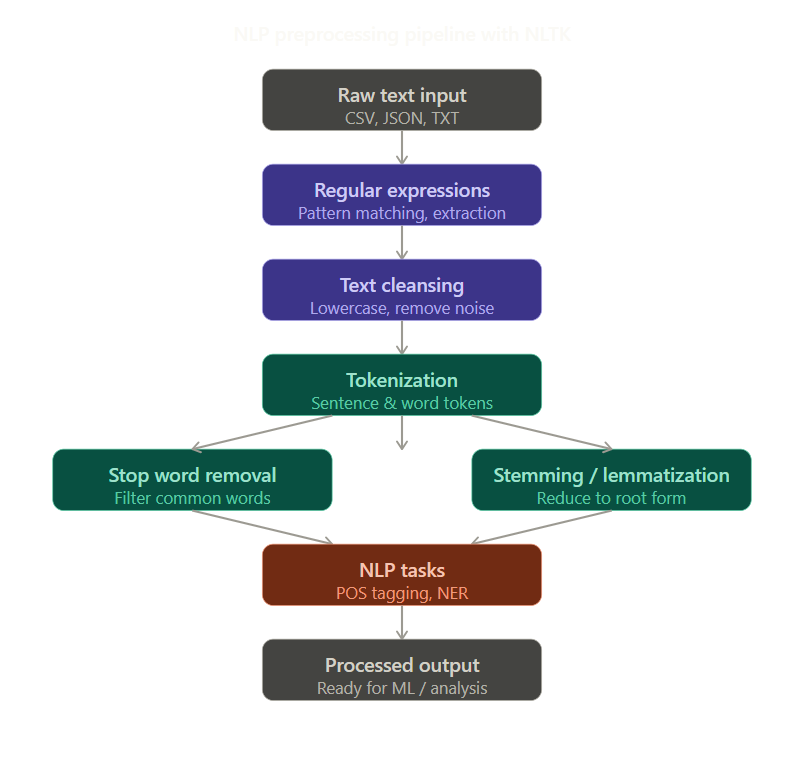

REFERENCES
 * https://www.nltk.org/

 * https://guides.library.upenn.edu/penntdm/python/nltk

* Working with NLTK corpora: https://www.nltk.org/book/ch02.html

 * https://cheatography.com/murenei/cheat-sheets/natural-language-processing-with-python-and-nltk/
